In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [50]:
train_data = pd.read_csv('train_data.csv')
test_data = pd.read_csv('test_data.csv')
X_train = train_data.iloc[:,1:]
y_train = train_data.iloc[:,0]
X_test = test_data.iloc[:,1:]
y_test = test_data.iloc[:,0]

1. **Linear** **Regression**


Text(0, 0.5, 'House Price')

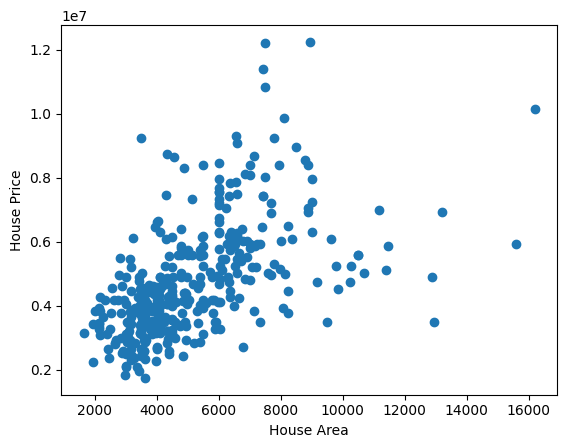

In [51]:
plt.scatter(X_train['area'],y_train)
plt.xlabel('House Area')
plt.ylabel('House Price')

In [52]:
#Implement standardscaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
preprocessor = ColumnTransformer(
    transformers=[
        ('num',StandardScaler(),['area','bedrooms','bathrooms']),
    ],
    remainder='passthrough'
)
X_train = pd.DataFrame(preprocessor.fit_transform(X_train))
X_test = pd.DataFrame(preprocessor.transform(X_test))

In [53]:
def cost_function_slr(x,y,w,b):
  m = len(x)
  total_cost = 0
  for i in range(m):
    f = w*x[i] + b
    total_cost += (f-y[i])**2
  total_cost = (1/(2*m)) * total_cost
  return total_cost

def gradient_function_slr(x,y,w,b):
  m = len(x)
  dc_dw=0
  dc_db=0
  for i in range(m):
    f = w*x[i] + b
    dc_dw += (f-y[i])*x[i]
    dc_db += (f-y[i])

  dc_dw=(1/m) * (dc_dw)
  dc_db=(1/m) * (dc_db)
  return dc_dw,dc_db

def gradient_descent_slr(x,y,w,b,alpha,iterations):
  w,b=0,0
  for i in range(1,iterations+1):
    dc_dw,dc_db=gradient_function_slr(x,y,w,b)
    w -= alpha*dc_dw
    b -= alpha*dc_db
    if(i%10==0):
      print(f"Iteration {i} : Cost Function = {cost_function_slr(x,y,w,b)}")

  return w,b

In [58]:
alpha=0.01
iterations=1000
w,b=gradient_descent_slr(X_train[0],y_train,0,0,alpha,iterations)

Iteration 10 : Cost Function = 10759096601649.318
Iteration 20 : Cost Function = 8999007729153.045
Iteration 30 : Cost Function = 7559418829550.669
Iteration 40 : Cost Function = 6381969081277.905
Iteration 50 : Cost Function = 5418924763493.504
Iteration 60 : Cost Function = 4631244134764.045
Iteration 70 : Cost Function = 3986994683915.282
Iteration 80 : Cost Function = 3460058588522.8647
Iteration 90 : Cost Function = 3029073900431.015
Iteration 100 : Cost Function = 2676568534042.5063
Iteration 110 : Cost Function = 2388251949333.0996
Iteration 120 : Cost Function = 2152435814474.9282
Iteration 130 : Cost Function = 1959560161777.069
Iteration 140 : Cost Function = 1801805827341.899
Iteration 150 : Cost Function = 1672777462771.336
Iteration 160 : Cost Function = 1567244268242.2483
Iteration 170 : Cost Function = 1480927936290.109
Iteration 180 : Cost Function = 1410329209558.5088
Iteration 190 : Cost Function = 1352586021179.2014
Iteration 200 : Cost Function = 1305357466804.7822


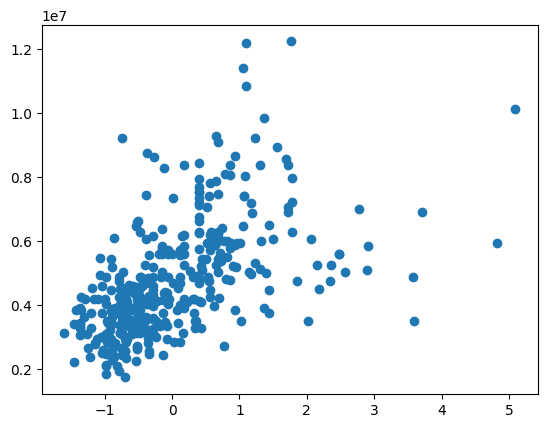

In [44]:
#visualization
x_sorted=np.sort(X_train[0])
plt.scatter(X_train[0],y_train)
plt.plot(x_sorted,w*x_sorted+b)

In [59]:
y_pred = w*X_test[0] + b
ss_res = np.sum((y_test-y_pred)**2)
ss_tot = np.sum((y_test-np.mean(y_test))**2)
r2 = 1 - (ss_res/ss_tot)
print("Accuracy:",r2*100)

Accuracy: 25.831405004662635


2. **Multiple Linear Regression**

In [60]:
def cost_function_mlr(x,y,w,b):
  m = len(x)
  total_cost = 0
  for i in range(m):
    f = np.dot(x.iloc[i],w) + b
    total_cost += (f-y[i])**2
  total_cost = (1/(2*m)) * total_cost
  return total_cost

def gradient_function_mlr(x,y,w,b):
  m = len(x)
  dc_dw=np.zeros(w.shape)
  dc_db=0
  for i in range(m):
    f = np.dot(x.iloc[i],w) + b
    dc_dw += (f-y[i])*x.iloc[i]
    dc_db += (f-y[i])

  dc_dw=(1/m) * (dc_dw)
  dc_db=(1/m) * (dc_db)
  return dc_dw,dc_db

def gradient_descent_mlr(x,y,w,b,alpha,iterations):
  for i in range(1,iterations+1):
    dc_dw,dc_db=gradient_function_mlr(x,y,w,b)
    w -= alpha*dc_dw
    b -= alpha*dc_db
    if(i%10==0):
      print(f"Iteration {i} : Cost Function = {cost_function_mlr(x,y,w,b)}")

  return w,b

In [61]:
#need to only add features whose correlation is high
def feature_selection(x,y,threshold):
  correlations = []
  for i in range(x.shape[1]):
    correlation = np.corrcoef(x.iloc[:,i],y)[0,1]
    correlations.append(correlation)
  correlations = np.array(correlations)
  selected_features =  np.abs(correlations) >= threshold
  print(f"Selected features : {selected_features}")
  return x.loc[:,selected_features]
X_selected = feature_selection(X_train,y_train,0.5)


Selected features : [ True False  True False False False False False False]


In [62]:
alpha=0.1
w=np.zeros(X_selected.shape[1])
b=0
w,b = gradient_descent_mlr(X_selected,y_train,w,b,alpha,iterations)

Iteration 10 : Cost Function = 2242951760294.7915
Iteration 20 : Cost Function = 975885704839.8276
Iteration 30 : Cost Function = 824205463871.7771
Iteration 40 : Cost Function = 805951328047.6627
Iteration 50 : Cost Function = 803746715551.1298
Iteration 60 : Cost Function = 803479826718.992
Iteration 70 : Cost Function = 803447465821.285
Iteration 80 : Cost Function = 803443537652.9718
Iteration 90 : Cost Function = 803443060439.4834
Iteration 100 : Cost Function = 803443002426.3474
Iteration 110 : Cost Function = 803442995369.3207
Iteration 120 : Cost Function = 803442994510.2272
Iteration 130 : Cost Function = 803442994405.5424
Iteration 140 : Cost Function = 803442994392.7687
Iteration 150 : Cost Function = 803442994391.2067
Iteration 160 : Cost Function = 803442994391.0156
Iteration 170 : Cost Function = 803442994390.9923
Iteration 180 : Cost Function = 803442994390.9889
Iteration 190 : Cost Function = 803442994390.988
Iteration 200 : Cost Function = 803442994390.9886
Iteration 2

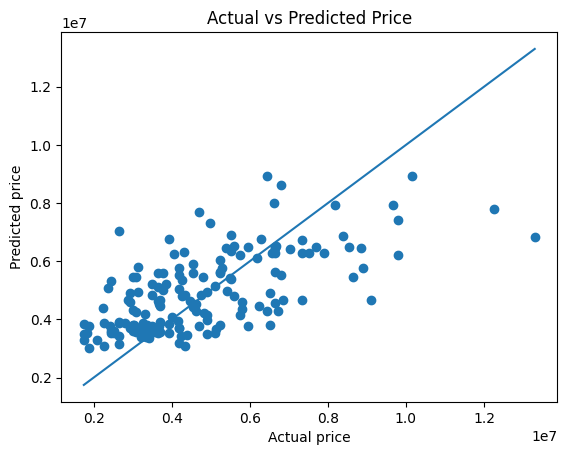

In [63]:
X_mlr_test = X_test.loc[:,X_selected.columns]
y_pred = np.dot(X_mlr_test, w) + b

plt.scatter(y_test, y_pred)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title("Actual vs Predicted Price")
plt.show()

In [64]:
y_pred = np.dot(X_mlr_test, w) + b

ss_res = np.sum((y_test - y_pred) ** 2)
ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)

r2 = 1 - (ss_res / ss_tot)

print("Accuracy:", r2*100)

Accuracy: 42.35252099711747


3.Polynomial regression
For this we can make use of the mlr functions already created


In [65]:
x = X_train[0]
X_poly = np.column_stack((x,x**2,x**3))
X_poly = pd.DataFrame(X_poly)
w = np.zeros(X_poly.shape[1])
alpha=0.01
iterations=5000
b=0
w,b=gradient_descent_mlr(X_poly,y_train,w,b,alpha,iterations)

Iteration 10 : Cost Function = 9699718777326.715
Iteration 20 : Cost Function = 7809626126340.413
Iteration 30 : Cost Function = 6413181093179.207
Iteration 40 : Cost Function = 5374858205003.107
Iteration 50 : Cost Function = 4596784403043.343
Iteration 60 : Cost Function = 4008249068034.888
Iteration 70 : Cost Function = 3558138508986.4434
Iteration 80 : Cost Function = 3209479476914.889
Iteration 90 : Cost Function = 2935503647142.1294
Iteration 100 : Cost Function = 2716808990233.9673
Iteration 110 : Cost Function = 2539312203361.826
Iteration 120 : Cost Function = 2392771651197.3877
Iteration 130 : Cost Function = 2269721763343.993
Iteration 140 : Cost Function = 2164704184679.6758
Iteration 150 : Cost Function = 2073712957706.8547
Iteration 160 : Cost Function = 1993794080513.3303
Iteration 170 : Cost Function = 1922756417086.7637
Iteration 180 : Cost Function = 1858962931870.6006
Iteration 190 : Cost Function = 1801179870898.318
Iteration 200 : Cost Function = 1748467750254.1057

In [66]:
x_test_single_feature = X_test[0] # Select only the first feature of X_test
X_poly = np.column_stack((
    x_test_single_feature,
    x_test_single_feature**2,
    x_test_single_feature**3
))

y_pred = np.dot(X_poly, w) + b

ss_res = np.sum((y_test - y_pred) ** 2)
ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)

r2 = 1 - (ss_res / ss_tot)

print("R² Score:", r2)
print("R² Percentage:", r2 * 100)

R² Score: 0.27450707512323147
R² Percentage: 27.45070751232315
